# **MODELLO DEFINITIVO: `VotingClassifier`**

### Preparazione dati

Leggo il nostro dict in `.pkl`

In [2]:
import pickle as pkl

with open('data/ottani_NIR.pkl', 'rb') as f:
    dizionario = pkl.load(f)
    
# dati train
train_ones = dizionario['train']['NIR']['ones']
train_zeros = dizionario['train']['NIR']['zeros']
train_labels = dizionario['train']['labels']

# dati test
test_ones = dizionario['test']['NIR']['ones']
test_zeros = dizionario['test']['NIR']['zeros']
test_labels = dizionario['test']['labels']


In [3]:
import numpy as np

train_x = np.concatenate((train_zeros, train_ones))
test_x = np.concatenate((test_zeros,test_ones))


importo neural network

In [4]:
import sys
sys.path.append("../ML_app")

from neural_network import neural_network

---

### SMOOTHING 

In [5]:
from scipy.signal import savgol_filter

window_size = 11
poly_order = 3

for i in range(train_x.shape[0]):
    train_x[i] = savgol_filter(train_x[i], window_size, poly_order)

for j in range(test_x.shape[0]):
    test_x[j] = savgol_filter(test_x[j], window_size, poly_order)

---

In [6]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier as RFC

In [7]:
random_state=None

### Migliori modelli trovati

In [8]:
nn_best = neural_network(epoche=20_000, nn_learning_rate=0.5, activation_function='sigmoide', random_state=random_state)
svm_best = SVC(C=5, kernel='linear', random_state=random_state, probability=True)
svm_best._estimator_type = "classifier"
rf_best = RFC(criterion='entropy', max_depth=5, max_features='log2', min_samples_leaf=1, n_estimators=100, random_state=random_state)

nn_pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", MinMaxScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(n_components=37)),
    
    # Step 3: Classificatore
    ("classify", nn_best) 
])

svm_pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", MinMaxScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(n_components=5)),
    
    # Step 3: Classificatore
    ("classify", svm_best) 
])

rf_pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", MinMaxScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    #("reduce_dim", PCA()),
    
    # Step 3: Classificatore
    ("classify", svm_best) 
])

## **SU QUALI SPETTRI SBAGLIANO I MODELLI?**

Facciamo un istogramma che mostra, durante cross-validation, quali sono gli spettri (tra i 48) su cui sbagliano di più i modelli. Vogliamo vedere se sbagliano tutti e tre nello stesso posto, oppure no. Perché se sbagliano tutti gli stessi spettri, non ha senso usare il majority rule!

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.base import clone

# possiamo anche farlo su più di 10 ripetizioni
n_repeats = 10

# Prepariamo gli array lunghi 48 riempiti di zeri
N_campioni = len(train_x)
errori_svm = np.zeros(N_campioni)
errori_rf = np.zeros(N_campioni)
errori_nn = np.zeros(N_campioni)

# Prepariamo le liste per raccogliere l'accuracy di ogni fold
scores_svm = []
scores_rf = []
scores_nn = []

rkf = RepeatedStratifiedKFold(n_splits=6, n_repeats=n_repeats, random_state=random_state)

# iteriamo sui fold
for train_index, test_index in rkf.split(train_x, train_labels):
    
    # Creiamo i set per questo specifico split
    X_train_fold, X_test_fold = train_x[train_index], train_x[test_index]
    y_train_fold, y_test_fold = train_labels[train_index], train_labels[test_index]
    
    # --- Modello SVM ---
    clone_svm = clone(svm_pipe).fit(X_train_fold, y_train_fold)
    pred_svm = clone_svm.predict(X_test_fold)
    
    errori_svm[test_index] += (pred_svm != y_test_fold)
    scores_svm.append(np.mean(pred_svm == y_test_fold)) # Calcolo accuracy del fold
    
    # --- Modello Random Forest ---
    clone_rf = clone(rf_pipe).fit(X_train_fold, y_train_fold)
    pred_rf = clone_rf.predict(X_test_fold)
    
    errori_rf[test_index] += (pred_rf != y_test_fold)
    scores_rf.append(np.mean(pred_rf == y_test_fold)) # Calcolo accuracy del fold
    
    # --- Modello Neurone ---
    clone_nn = clone(nn_pipe).fit(X_train_fold, y_train_fold)
    pred_nn = clone_nn.predict(X_test_fold)
    
    errori_nn[test_index] += (pred_nn != y_test_fold)
    scores_nn.append(np.mean(pred_nn == y_test_fold)) # Calcolo accuracy del fold
    
svm_mean_acc = np.mean(scores_svm)
svm_std_acc = np.std(scores_svm)

rf_mean_acc = np.mean(scores_rf)
rf_std_acc = np.std(scores_rf)

nn_mean_acc = np.mean(scores_nn)
nn_std_acc = np.std(scores_nn)

# --- STAMPA DEI RISULTATI ---
print("--- RISULTATI ACCURACY (Cross-Validation) ---")
print(f"SVM          : {svm_mean_acc:.4f} ± {svm_std_acc:.4f}")
print(f"Random Forest: {rf_mean_acc:.4f} ± {rf_std_acc:.4f}")
print(f"Neurone      : {nn_mean_acc:.4f} ± {nn_std_acc:.4f}")


--- RISULTATI ACCURACY (Cross-Validation) ---
SVM          : 0.9792 ± 0.0466
Random Forest: 0.9521 ± 0.0649
Neurone      : 0.9417 ± 0.0664


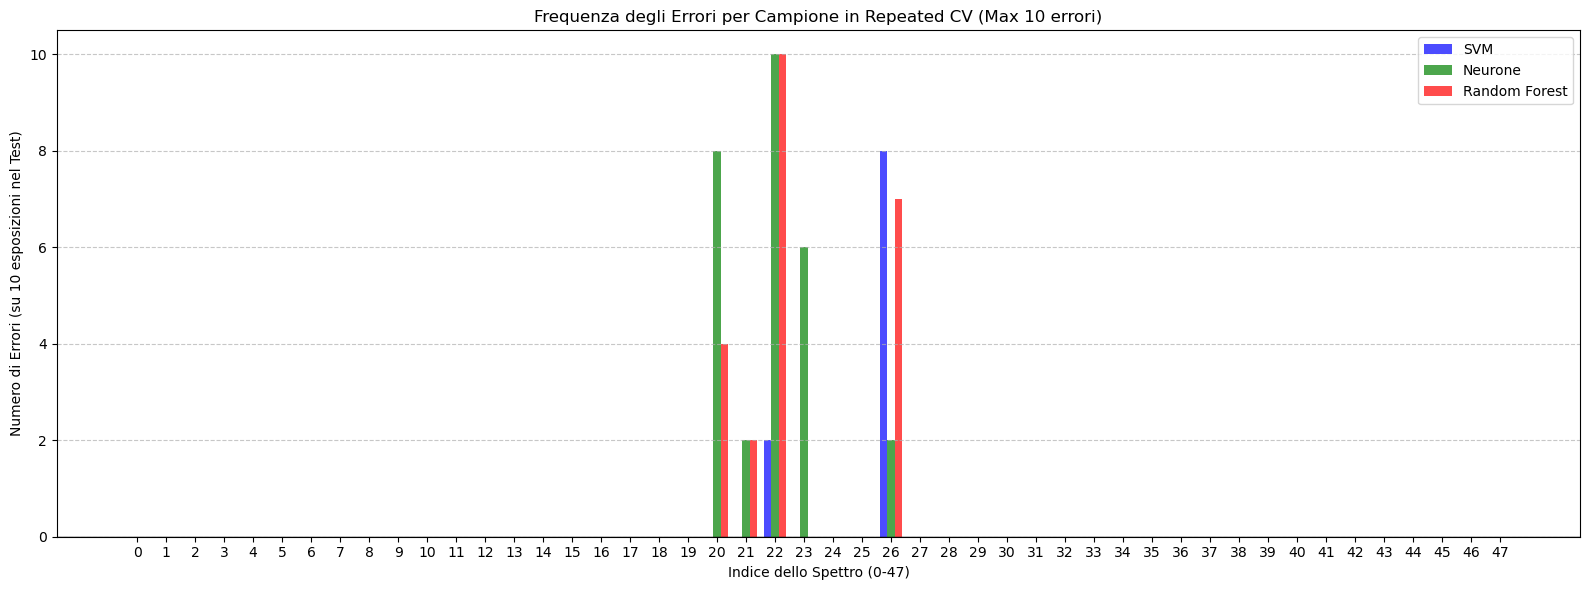

In [10]:
# Grafico
indici = np.arange(N_campioni)
larghezza_barra = 0.25

plt.figure(figsize=(16, 6))

# Creiamo tre barre affiancate per ogni campione
plt.bar(indici - larghezza_barra, errori_svm, width=larghezza_barra, label='SVM', color='blue', alpha=0.7)
plt.bar(indici, errori_nn, width=larghezza_barra, label='Neurone', color='green', alpha=0.7)
plt.bar(indici + larghezza_barra, errori_rf, width=larghezza_barra, label='Random Forest', color='red', alpha=0.7)

plt.title(f'Frequenza degli Errori per Campione in Repeated CV (Max {n_repeats} errori)')
plt.xlabel('Indice dello Spettro (0-47)')
plt.ylabel(f'Numero di Errori (su {n_repeats} esposizioni nel Test)')
plt.xticks(indici) # Mostra tutti i numerini sull'asse X
plt.axhline(0, color='black', linewidth=1)
#plt.yticks(np.arange(n_repeats+1)) # Asse Y va da 0 a n_repeats+1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

> ⚠️ **Tutti e tre sbagliano spessissimo sul 22!**

> ‼️ Neural network sbaglia con molta convinzione il 26, mentre gli altri due (almeno nell'ultima ripetizione) no

In [24]:
print('svm', clone_svm.predict_proba(train_x)[26])
print('nn', clone_nn.predict_proba(train_x)[26])
print('rf', clone_rf.predict_proba(train_x)[26])

svm [0.2616178 0.7383822]
nn [0.99167801 0.00832199]
rf [0.20566189 0.79433811]


---

## **MODELLO FINALE**

In [14]:
from sklearn.ensemble import VotingClassifier

# Supponiamo tu abbia i tuoi 3 modelli già configurati con i best_params
clf_svm = clone(svm_pipe)
clf_nn = clone(nn_pipe)
clf_rf = clone(rf_pipe)

# Pesi basati sull'accuracy della CV (es. 0.99, 0.95, 0.89) divisi per la std!
pesi = [svm_mean_acc/svm_std_acc, nn_mean_acc/nn_std_acc, rf_mean_acc/rf_std_acc]

ensemble = VotingClassifier(
    estimators=[
        ('svm', clf_svm), 
        ('neurone', clf_nn), 
        ('random_forest', clf_rf)
    ],
    voting='soft', # 'hard' fa la regola della maggioranza, 'soft' somma le probabilità
    weights=pesi
)

# Lo alleni sui 48 e testi sui 12
ensemble.fit(train_x, train_labels)

print('test interno:', ensemble.score(train_x, train_labels))
predizioni_test_interno = ensemble.predict(train_x)
print('test esterno:', ensemble.score(test_x, test_labels))
predizioni_test_esterno = ensemble.predict(test_x)


test interno: 0.9791666666666666
test esterno: 1.0


È sempre il 22 che dà noia!!!

In [23]:
predizioni_test_interno

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])